In [ ]:
import numpy as np

'''
computation of the aberrations of a thick lens.
done according to the work
Third-order aberration coefficients of a thick lens
Antonin Mikš* and Jiří Novák
Czech Technical University in Prague, Faculty of Civil Engineering, Department of Physics,
Thakurova 7, Prague 16629, Czech Republic
*Corresponding author: miks@fsv.cvut.cz
Received 17 August 2012; revised 9 October 2012; accepted 13 October 2012;
posted 16 October 2012 (Doc. ID 174533); published 16 November 2012

All units in mm

'''
#### parameters
d = 2 # thickness at vertex
r1 = 12.7 # first surface curvsature radius
r2 = -12.7 # second surface curvsature radius

X = (r1+r2)/(r2-r1)   ####SHAPE FACTOR
RI = 1.5  ##lens RI


phi1 = (RI-1)/r1
phi2 = (RI-1)/r2
phi  = phi1 + phi2 - d*phi1*phi2/RI

S_0I = (1/(RI-1)**2) * ( (RI+2)/RI*phi1**2 - (2*RI+1)*phi1 + RI**2)
print (S_0I)


8.384545435757538


focal length[mm] =  22.0 ; curvature radius= 66.0 [mm]


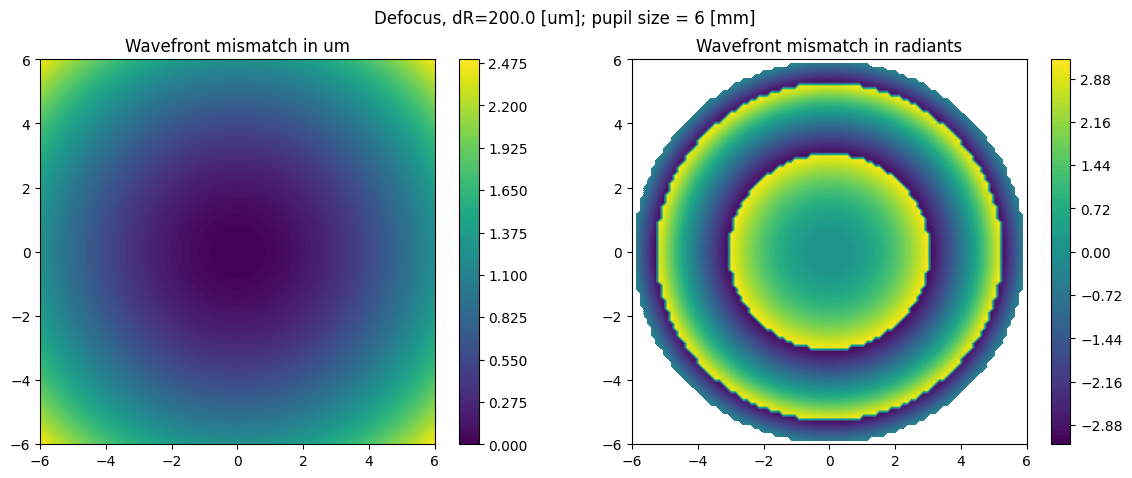

In [ ]:

'''
computation of the defocus aberrations
All units in mm
'''
import matplotlib.pyplot as plt
import numpy as np

pupil_radius = 6 ### mm

x     = np.linspace(-pupil_radius,pupil_radius,100)
xx,yy = np.meshgrid(x,x)
rho2  = xx**2 + yy**2

DioptricPower = 1/22 ## in mm^-1
focal = 1/DioptricPower
CurvRadius = 2*RI/DioptricPower
print ('focal length[mm] = ',focal,'; curvature radius=',CurvRadius,'[mm]')

mask = rho2 < pupil_radius**2
maschera = np.zeros_like(xx)
maschera[mask] = 1
maschera[~mask] = 0

deltaR = 0.2 # mm  is the delta in the curcature radius

W   = RI * rho2 *deltaR / 2. / CurvRadius**2
wav = 0.6325e-3 ### in mm
k0  = 2*np.pi/0.6325E-3  ## 1/mm

F,A = plt.subplots(1,2,figsize=(14,5))
I0  = A[0].contourf(xx,yy,W*1000,100) ##multiply by 1000 toget in um
plt.colorbar(I0,ax=A[0])
A[0].set_title('Wavefront mismatch in um')
Ww  = ((W*k0* maschera + np.pi) % (2*np.pi) - np.pi)

Ww_masked = np.ma.array(Ww, mask=(maschera==0))

I1  = A[1].contourf(xx,yy,Ww_masked,100)
plt.colorbar(I1,ax=A[1])
A[1].set_title('Wavefront mismatch in radiants')
F.suptitle('Defocus, dR='+str(np.round(deltaR*1000,1))+' [um]; pupil size = '+str(pupil_radius)+' [mm]')
plt.show()

22.0 66.0


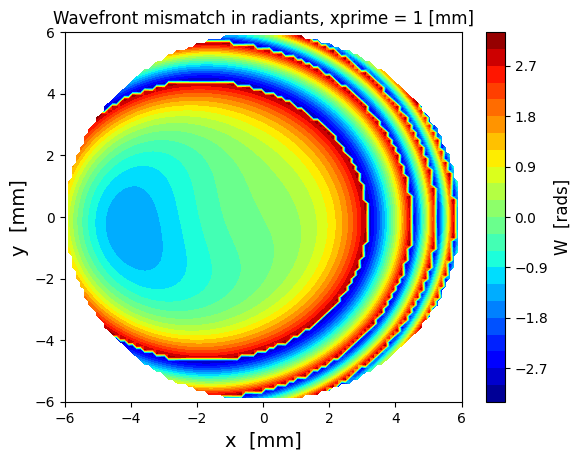

In [ ]:
### general description of the wave front mismatch
####Seidel equations
#####  general case described by genierc coefficients


import matplotlib.pyplot as plt
import numpy as np

pupil_radius = 6 ### mm
wav = 0.6325e-3 ### in mm
k0  = 2*np.pi/0.6325E-3  ## 1/mm
RI = 1.5

mask = rho2 < pupil_radius**2
maschera = np.zeros_like(xx)
maschera[mask] = 1
maschera[~mask] = 0

x     = np.linspace(-pupil_radius,pupil_radius,100)
xx,yy = np.meshgrid(x,x)
rho2  = xx**2 + yy**2
DioptricPower = 1/22 ## in mm^-1
focal = 1/DioptricPower
xprime = +1 ##mm off axis coordinate

CurvRadius = 2*RI/DioptricPower
print (focal,CurvRadius)
C040 = 0.1e-5
C131 = 0.5e-5
C222 = 1e-5
C220 = 1e-5
C311 = 0e-5

W040 = C040 * rho2**2
W131 = C131 * xprime * rho2*xx
W222 = (C222+C220)*xprime**2*xx+C220*xprime**2*yy
W311 = C311 * xprime**3 * xx

Wtot = W040 + W131+W222+W311
Ww  = ((Wtot*k0* maschera + np.pi) % (2*np.pi) - np.pi)
Ww_masked = np.ma.array(Ww, mask=(maschera==0))

plt.figure()
im = plt.contourf(xx,yy,Ww_masked,20,cmap='jet')
plt.xlabel('x  [mm]',fontsize=14)
plt.ylabel('y  [mm]',fontsize=14)

cbar = plt.colorbar(im)
cbar.set_label("W  [rads]", fontsize=12)
plt.title('Wavefront mismatch in radiants, xprime = '+str(xprime)+' [mm]')
plt.show()
